# E-Commerce Sales Analysis

## Business Problem

The goal of this project is to analyze e-commerce sales data and identify key business insights related to sales performance, profitability, products, categories, and regions.

## Dataset

The dataset contains sales transaction data including product information, categories, regions, sales revenue, and profit.

## Project Objectives

1. Analyze sales and profit by category.
2. Analyze sales and profit by region.
3. Identify top-performing products by sales and profit.
4. Analyze sales trends over time.
5. Evaluate profitability across categories.
6. Provide business recommendations based on the analysis.


# Data Loading and Initial Inspection

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\koval\Downloads\ecommerce_sales_data.csv")

print("First 5 rows:")
print(df.head())



First 5 rows:
   Order Date Product Name     Category Region  Quantity  Sales  Profit
0  2024-12-31      Printer       Office  North         4   3640  348.93
1  2022-11-27        Mouse  Accessories   East         7   1197  106.53
2  2022-05-11       Tablet  Electronics  South         5   5865  502.73
3  2024-03-16        Mouse  Accessories  South         2    786  202.87
4  2022-09-10        Mouse  Accessories   West         1    509  103.28


# Data Understanding

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

Dataset Shape:
(3500, 7)

Columns:
Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='str')

Data Types:
Order Date          str
Product Name        str
Category            str
Region              str
Quantity          int64
Sales             int64
Profit          float64
dtype: object

Missing Values:
Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

Duplicates:
0


## Initial Observations

- The dataset contains 3,500 rows and 7 columns.
- There are no missing values in any column.
- There are no duplicate records.
- The dataset contains information about sales transactions, including product, category, region, quantity sold, sales revenue, and profit.
- The Order Date column is currently stored as a string and will need to be converted to datetime format for time-series analysis.

# Data Cleaning

## Converting Date Column

The Order Date column is stored as a string. To enable time-based analysis, it must be converted to datetime format.

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[us]
 1   Product Name  3500 non-null   str           
 2   Category      3500 non-null   str           
 3   Region        3500 non-null   str           
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 191.5 KB


### Cleaning Summary

The Order Date column was successfully converted from string format to datetime format.

This transformation enables time-based analysis such as monthly sales trends, yearly performance comparisons, and seasonal pattern identification.

# Exploratory Data Analysis (EDA)

## Descriptive Statistics

In this section, we examine the basic statistical properties of the numerical variables in the dataset.

The goal is to understand the distribution of sales, profit, and quantity values before performing deeper analysis.

In [6]:
df.describe()

,Order Date,Quantity,Sales,Profit
count,3500,3500.000000,3500.000000,3500.000000
mean,2023-07-13 00:53:53.828571,4.931714,3047.966000,527.047203
min,2022-01-01 00:00:00,1.000000,51.000000,6.970000
25%,2022-10-16 18:00:00,3.000000,1049.500000,158.695000
50%,2023-07-21 12:00:00,5.000000,2350.500000,361.070000
75%,2024-04-16 06:00:00,7.000000,4537.000000,729.125000
max,2024-12-31 00:00:00,9.000000,10782.000000,2946.930000
std,NaN,2.575895,2440.213237,504.139732


### Statistical Observations

- The average quantity sold per order is approximately 5 units.
- The average sales value is 3,047.97, while the median sales value is 2,350.50.
- The difference between the mean and median sales suggests the presence of high-value orders.
- The average profit per order is 527.05.
- Profit distribution also appears to be influenced by a small number of highly profitable transactions.

## Sales by Category

In this section, we analyze sales and profit performance across product categories.

The objective is to identify which categories contribute the most to revenue and profitability.

In [7]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum()

category_summary

,Sales,Profit
Category,,
Accessories,4247591,736084.74
Electronics,5326074,923185.59
Office,1094216,185394.88


### Category Performance Insights

- Electronics generated the highest sales revenue, reaching 5.33 million.
- Electronics also produced the highest total profit, exceeding 923 thousand.
- Accessories ranked second in both sales and profitability.
- Office products contributed the smallest share of both revenue and profit.
- Based on these results, Electronics appears to be the most valuable category for the business.

## Sales and Profit by Region

In this section, we evaluate the performance of different geographical regions.

The goal is to determine which regions generate the highest sales and profit.

In [8]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum()

region_summary

,Sales,Profit
Region,,
East,2675110,464888.46
North,2488773,426314.75
South,2659548,458103.27
West,2844450,495358.73


### Regional Performance Insights

- The West region generated the highest sales revenue, reaching 2.84 million.
- The West region also achieved the highest total profit, exceeding 495 thousand.
- The East and South regions showed similar sales performance.
- The North region recorded the lowest sales and profit among all regions.
- Based on the results, the West region appears to be the strongest market for the business.

## Sales Trend Over Time

In this section, we analyze how sales changed over time.

The objective is to identify trends, seasonality, and potential growth patterns.

In [9]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Sales'].sum()

monthly_sales

YearMonth
2022-01    341544
2022-02    208775
2022-03    294660
2022-04    230624
2022-05    314295
2022-06    273851
2022-07    214627
2022-08    296242
2022-09    240211
2022-10    324989
2022-11    257111
2022-12    259041
2023-01    343256
2023-02    313931
2023-03    303391
2023-04    280808
2023-05    346481
2023-06    251686
2023-07    320798
2023-08    388428
2023-09    303409
2023-10    253145
2023-11    306195
2023-12    375064
2024-01    282814
2024-02    179708
2024-03    341563
2024-04    310444
2024-05    373911
2024-06    314268
2024-07    309515
2024-08    240269
2024-09    341926
2024-10    314135
2024-11    291769
2024-12    324997
Freq: M, Name: Sales, dtype: int64

In [10]:
import matplotlib.pyplot as plt

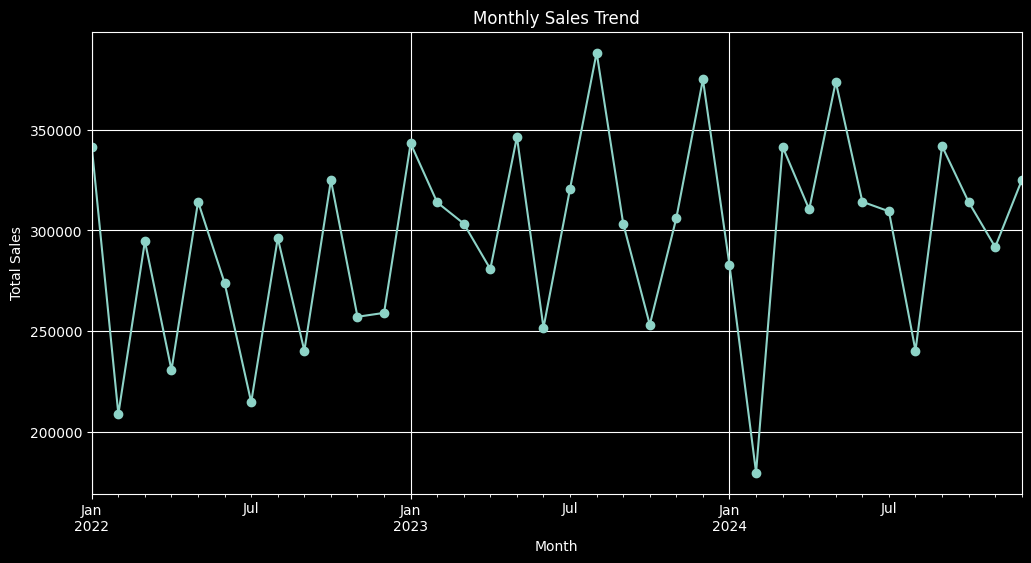

In [12]:
plt.figure(figsize=(12,6))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.grid(True)

plt.show()

### Key Insights

- Monthly sales show considerable fluctuations across the analyzed period.
- No consistent upward or downward trend is observed.
- Sales peaks occur multiple times throughout the dataset, suggesting potential seasonal effects.
- February 2024 recorded the lowest sales value and stands out as a potential anomaly.
- Overall business performance remains relatively stable despite month-to-month variability.

## Top Performing Products

In this section, we identify the products that generate the highest sales revenue.

The objective is to determine which products contribute the most to the company's overall performance.

In [13]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: Sales, dtype: int64

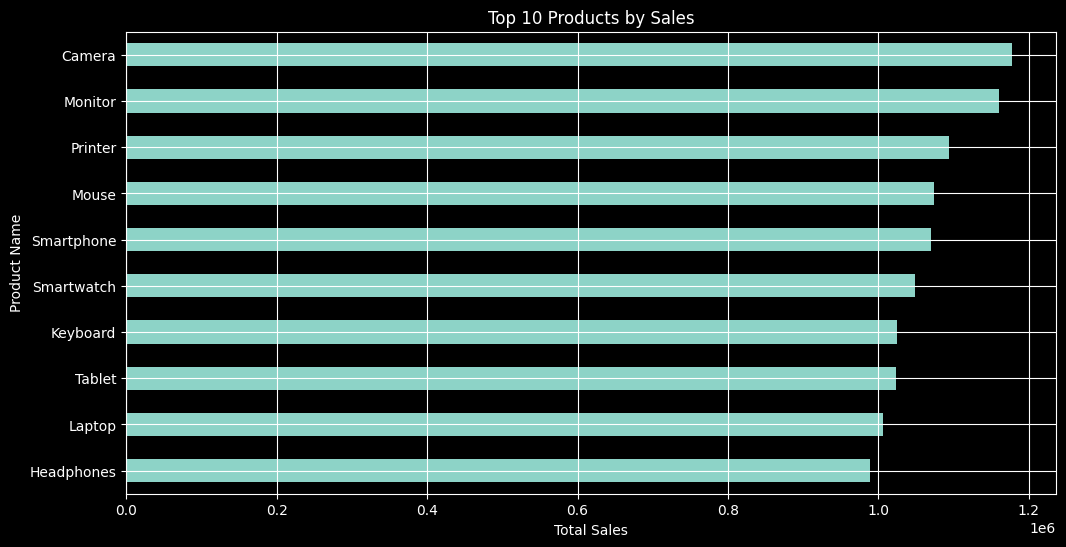

In [15]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')

plt.grid(True)

plt.show()

### Key Insights

- Camera generated the highest sales revenue, reaching approximately 1.18 million.
- Monitor and Printer ranked second and third, respectively.
- The difference between the highest and lowest products in the top 10 is relatively small, indicating balanced product performance.
- Electronics-related products dominate the ranking, confirming the strong performance of the Electronics category observed earlier.
- The company does not appear to rely on a single product for revenue generation, which reduces business risk.

## Top Performing Products by Profit

In this section, we analyze which products generate the highest profit.

Revenue is important, but profitability provides a better understanding of business value.

In [16]:
top_profit_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_products

Product Name
Camera        207630.99
Monitor       202028.17
Mouse         185763.69
Laptop        185756.81
Printer       185394.88
Smartphone    183296.97
Smartwatch    178995.81
Keyboard      175814.68
Headphones    172478.20
Tablet        167505.01
Name: Profit, dtype: float64

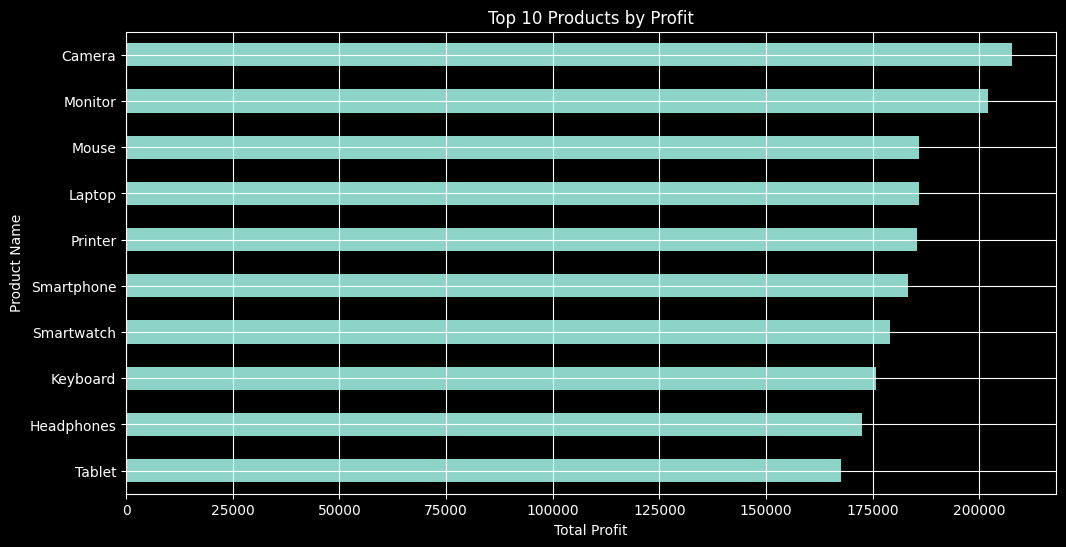

In [17]:
plt.figure(figsize=(12,6))

top_profit_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')

plt.grid(True)

plt.show()

### Key Insights

- Camera generated the highest total profit, exceeding 207 thousand.
- Monitor ranked second in profitability with more than 202 thousand in profit.
- Laptop generated relatively high profit despite not being among the top three products by sales.
- The profitability ranking differs slightly from the sales ranking, indicating differences in product margins.
- High-revenue products generally also generate high profit, suggesting a healthy business model.

## Profit Margin Analysis

In this section, we evaluate profit margins across product categories.

Profit margin helps identify which categories generate the highest profit relative to their sales.

In [18]:
category_margin = df.groupby('Category')[['Sales', 'Profit']].sum()

category_margin['Profit Margin (%)'] = (
    category_margin['Profit'] / category_margin['Sales']
) * 100

category_margin

,Sales,Profit,Profit Margin (%)
Category,,,
Accessories,4247591,736084.74,17.329464
Electronics,5326074,923185.59,17.333323
Office,1094216,185394.88,16.943170


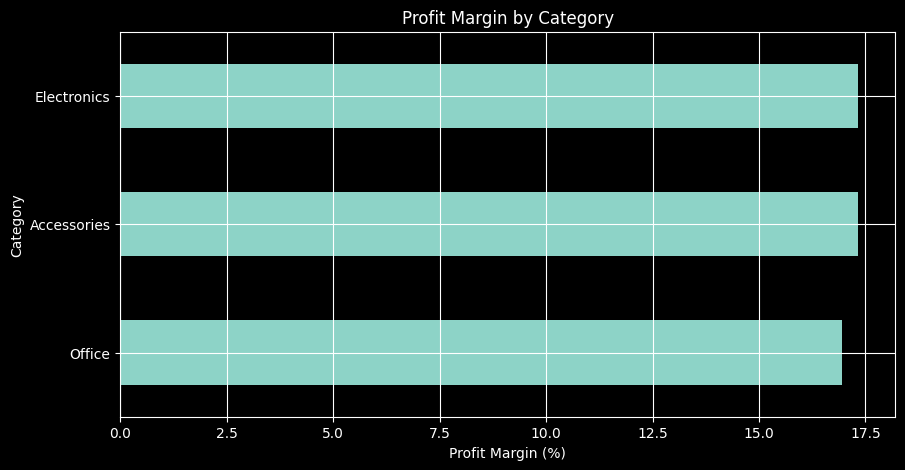

In [19]:
plt.figure(figsize=(10,5))

category_margin['Profit Margin (%)'].sort_values().plot(kind='barh')

plt.title('Profit Margin by Category')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Category')

plt.grid(True)

plt.show()

### Key Insights

- Electronics achieved the highest profit margin at approximately 17.33%.
- Accessories showed a nearly identical profit margin to Electronics.
- Office products generated the lowest profit margin at 16.94%.
- Profit margins are relatively consistent across all categories.
- The small differences in margins suggest a balanced pricing and profitability strategy.

## Profit by Region

In this section, we analyze profitability across different regions.

The objective is to identify which regions contribute the most to overall business profit.

In [20]:
region_profit = (
    df.groupby('Region')['Profit']
    .sum()
    .sort_values(ascending=False)
)

region_profit

Region
West     495358.73
East     464888.46
South    458103.27
North    426314.75
Name: Profit, dtype: float64

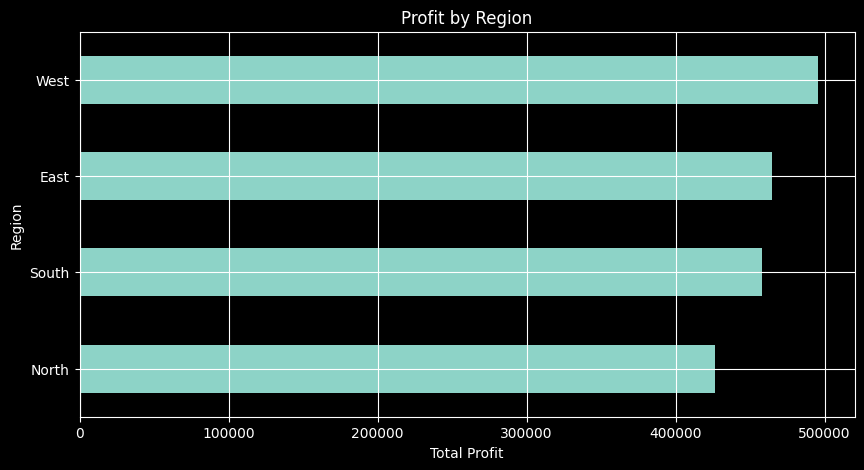

In [21]:
plt.figure(figsize=(10,5))

region_profit.sort_values().plot(kind='barh')

plt.title('Profit by Region')
plt.xlabel('Total Profit')
plt.ylabel('Region')

plt.grid(True)

plt.show()

### Key Insights

- The West region generated the highest total profit, reaching approximately 495 thousand.
- East and South regions showed similar profitability levels.
- The North region produced the lowest total profit.
- The profitability ranking closely matches the sales ranking observed earlier.
- This suggests that regional sales performance is strongly correlated with profitability.

# Final Conclusions

## Summary of Findings

- Electronics generated the highest sales revenue and total profit among all product categories.
- The West region delivered the strongest business performance in terms of both sales and profit.
- Monthly sales remained relatively stable, although noticeable fluctuations were observed across individual months.
- Camera and Monitor were identified as the top-performing products by both sales and profit.
- Profit margins were consistent across categories, indicating a balanced and sustainable profitability structure.

## Business Recommendations

- Continue prioritizing Electronics products, as they contribute the most to overall revenue and profit.
- Investigate the drivers behind the strong performance of the West region and replicate successful strategies in other regions.
- Analyze periods of unusually low sales, particularly February 2024, to identify potential operational or market-related issues.
- Maintain a diversified product portfolio to reduce dependence on individual products.
- Focus marketing and inventory planning on high-performing products such as Camera and Monitor.